[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter4_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 4: Portfolio Optimization

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and number of Lecture 4:
- US sector ETFs, multi-asset ETFs (equities, Treasuries, credit, gold), BVB blue chips, BET and BET-TR (course repository, `data/market`);
- the one-month risk-free rate (Kenneth French Data Library).

In [1]:
import os
import io
import re
import json
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

## Data

- ETFs and stocks: adjusted prices; indices (BET, BET-TR): closing values.
- Joint analyses join the **prices** on common days, then take month-end returns.
- BVB: days with a daily log return above 0.5 in absolute value are treated as data errors.

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
BNR_XML = 'https://curs.bnr.ro/files/xml/years/nbrfxrates{}.xml'

SECTORS = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']        # din dec. 1998
SECTOR_NAMES = {'XLB': 'Materials', 'XLE': 'Energy', 'XLF': 'Financials', 'XLI': 'Industrials',
                'XLK': 'Technology', 'XLP': 'Cons. staples', 'XLU': 'Utilities', 'XLV': 'Health care',
                'XLY': 'Cons. discretionary'}
MULTI = ['SPY', 'EFA', 'EEM', 'TLT', 'IEF', 'LQD', 'HYG', 'GLD']                  # HYG din apr. 2007
MULTI_NAMES = {'SPY': 'US equities', 'EFA': 'Developed ex-US', 'EEM': 'Emerging markets',
               'TLT': 'US Treasuries 20y+', 'IEF': 'US Treasuries 7-10y', 'LQD': 'Investment-grade credit',
               'HYG': 'High-yield credit', 'GLD': 'Gold'}
BVB = ['TLV', 'SNP', 'BRD', 'TGN', 'SNG', 'SNN', 'EL', 'TEL']                      # listate inainte de 2014-09
BVB_NAMES = {'TLV': 'Banca Transilvania', 'SNP': 'OMV Petrom', 'BRD': 'BRD-GSG', 'TGN': 'Transgaz',
             'SNG': 'Romgaz', 'SNN': 'Nuclearelectrica', 'EL': 'Electrica', 'TEL': 'Transelectrica'}

_CACHE = {}


def read_market(symbol):
    """Seria data/market/<SIMBOL>.csv."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(symbol):
    """Pretul folosit: adjusted_close pentru ETF/actiuni (.US, .RO), close pentru indici si cripto."""
    d = read_market(symbol)
    col = 'close' if symbol.endswith('.INDX') or symbol.endswith('.CC') or symbol == 'BET' else 'adjusted_close'
    s = d[col].astype(float)
    return s[s > 0].rename(symbol)


def prices(symbols, start=None, end=None):
    """Preturi aliniate: join pe zilele comune (analiza comuna -> intai join pe preturi)."""
    p = pd.concat([price(s) for s in symbols], axis=1).dropna()
    return p.loc[start:end]


def log_returns(p):
    """Randamente log pe un tabel deja aliniat (zile comune)."""
    return np.log(p).diff().dropna()


def french_rf():
    """Rata fara risc lunara (T-bill la o luna) din fisierul Fama-French cu 3 factori, in zecimal."""
    if 'rf' in _CACHE:
        return _CACHE['rf']
    url = FRENCH + 'F-F_Research_Data_Factors_CSV.zip'
    raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    text = z.read(z.namelist()[0]).decode('latin-1')
    rows = []
    for line in text.splitlines():
        parts = [x.strip() for x in line.split(',')]
        if len(parts) == 5 and len(parts[0]) == 6 and parts[0].isdigit():
            rows.append((parts[0], float(parts[4]) / 100.0))
        elif rows and not (len(parts[0]) == 6 and parts[0].isdigit()):
            break
    rf = pd.Series(dict(rows))
    rf.index = pd.to_datetime(rf.index, format='%Y%m') + pd.offsets.MonthEnd(0)
    _CACHE['rf'] = rf.rename('RF')
    return _CACHE['rf']


def monthly_returns(symbols, start=None):
    """Randamente lunare simple din preturile de sfarsit de luna (zile comune)."""
    p = prices(symbols).resample('ME').last()
    return p.pct_change().dropna().loc[start:]


def bnr_rate(currency='USD', start=2014, end=2026):
    """Cursul de referinta BNR: lei pentru o unitate de valuta (arhivele XML anuale)."""
    key = ('bnr', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(start, end + 1):
        xml = urllib.request.urlopen(urllib.request.Request(BNR_XML.format(y), headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"( multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(2))))
    s = pd.Series(dict(rows)).sort_index()
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.rename(f'{currency}RON')
    return _CACHE[key]

## Style, estimators and backtest engine

- Weights: 1/N, MV (tangency), MV-LO, GMV, GMV-LO, GMV-LW (Ledoit–Wolf, constant correlation), ERC, HRP.
- Backtest: 60-month rolling window, monthly rebalancing, turnover from drifted weights.
- Inference: HAC test of Ledoit–Wolf (2008) and circular block bootstrap for Sharpe ratio differences.

In [3]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
PALETTE = [MainBlue, IDAred, Forest, Amber, Orange, Purple, Crimson, '#795548', '#17A2B8', '#6F42C1', '#20C997']
EWcol    = '#D63384'   # culoarea portofoliului 1/N (niciodata gri pentru serii)

SEED = 42
MAX_ABS_RET = 0.5        # prag pentru erori de date in seriile BVB (log-randament zilnic)


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


US_END = '2026-07-31'
BVB_END = '2026-08-31'
WINDOW = 60
STRATS = ['1/N', 'MV', 'MV-LO', 'GMV', 'GMV-LO', 'GMV-LW', 'ERC', 'HRP']
BVB_STRATS = ['1/N', 'MV-LO', 'GMV-LO', 'GMV-LW', 'ERC', 'HRP']
SCOL = {'1/N': EWcol, 'MV': IDAred, 'MV-LO': Orange, 'GMV': Amber, 'GMV-LO': Purple,
        'GMV-LW': MainBlue, 'ERC': Forest, 'HRP': '#17A2B8'}
COMBINED = SECTORS + [a for a in MULTI if a != 'SPY']
UNIVERSES = {'Sectors': SECTORS, 'Multi-asset': MULTI, 'Combined': COMBINED}


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def us_monthly(symbols, start=None, end=US_END):
    """Randamente lunare simple (totale) si in exces fata de RF, pe lunile comune."""
    r = monthly_returns([s + '.US' for s in symbols]).loc[start:end]
    r.columns = symbols
    rf = french_rf().reindex(r.index)
    ok = rf.notna()
    r, rf = r[ok], rf[ok]
    return r, r.sub(rf, axis=0), rf


def bvb_monthly(symbols=BVB, bench=('BETTR.INDX', 'BET'), end=BVB_END):
    """Randamente lunare BVB (RON) din randamente zilnice filtrate (|r| > 0.5 = eveniment neajustat)."""
    cols = [s + '.RO' for s in symbols] + list(bench)
    p = prices(cols)
    lr = log_returns(p)
    bad = lr.abs() > MAX_ABS_RET
    lr = lr.mask(bad, 0.0)
    m = np.exp(lr.resample('ME').sum()) - 1
    m = m.loc[:end].iloc[1:]                     # prima luna este incompleta
    m.columns = list(symbols) + ['BET-TR' if b.startswith('BETTR') else b for b in bench]
    removed = {c.replace('.RO', ''): [str(d.date()) for d in lr.index[bad[c]]] for c in cols if bad[c].any()}
    return m, removed


def lw_cc(X):
    """Ledoit-Wolf (2004): shrinkage spre tinta cu corelatie constanta. Intoarce (Sigma, delta)."""
    X = np.asarray(X, float)
    T, N = X.shape
    Y = X - X.mean(0)
    S = Y.T @ Y / T
    var = np.diag(S).reshape(-1, 1)
    sd = np.sqrt(var)
    rbar = (np.sum(S / (sd @ sd.T)) - N) / (N * (N - 1))
    F = rbar * (sd @ sd.T)
    np.fill_diagonal(F, np.diag(S))
    Y2 = Y ** 2
    pi_mat = Y2.T @ Y2 / T - S ** 2
    pi_hat = pi_mat.sum()
    gamma_hat = np.linalg.norm(S - F, 'fro') ** 2
    theta = (Y ** 3).T @ Y / T - np.tile(var, (1, N)) * S
    np.fill_diagonal(theta, 0.0)
    rho_hat = np.trace(pi_mat) + rbar * np.sum(((1 / sd) @ sd.T) * theta)
    kappa = (pi_hat - rho_hat) / gamma_hat
    delta = max(0.0, min(1.0, kappa / T))
    return delta * F + (1 - delta) * S, delta


def w_ew(n):
    """Portofoliul 1/N."""
    return np.ones(n) / n


def w_gmv(S):
    """Portofoliul de varianta minima globala: S^-1 1 / 1' S^-1 1."""
    x = np.linalg.solve(S, np.ones(len(S)))
    return x / x.sum()


def w_tan(mu, S):
    """Portofoliul tangent (Sharpe maxim) cu vanzari in lipsa: S^-1 mu / 1' S^-1 mu."""
    x = np.linalg.solve(S, mu)
    return x / x.sum()


def w_long_only(S, mu=None):
    """Varianta minima (mu=None) sau Sharpe maxim cu ponderi 0 <= w <= 1, suma 1 (SLSQP)."""
    n = len(S)
    if mu is None:
        f = lambda w: w @ S @ w
    else:
        f = lambda w: -(w @ mu) / np.sqrt(w @ S @ w)
    res = minimize(f, np.ones(n) / n, method='SLSQP', bounds=[(0, 1)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
                   options={'ftol': 1e-12, 'maxiter': 500})
    w = np.clip(res.x, 0, None)
    return w / w.sum()


def w_erc(S):
    """Contributii egale la risc (Maillard, Roncalli, Teiletche 2010): min 0.5 y'Sy - sum(log y)/n."""
    n = len(S)
    b = np.ones(n) / n
    f = lambda y: 0.5 * y @ S @ y - b @ np.log(y)
    grad = lambda y: S @ y - b / y
    y0 = 1 / np.sqrt(np.diag(S))
    res = minimize(f, y0 / y0.sum(), jac=grad, method='L-BFGS-B', bounds=[(1e-12, None)] * n,
                   options={'ftol': 1e-15, 'gtol': 1e-12, 'maxiter': 2000})
    return res.x / res.x.sum()


def hrp_tree(S):
    """Arborele HRP: distanta d_ij = sqrt((1 - rho_ij)/2), legatura simpla (single linkage)."""
    sd = np.sqrt(np.diag(S))
    C = S / np.outer(sd, sd)
    D = np.sqrt(np.clip((1 - C) / 2, 0, None))
    np.fill_diagonal(D, 0)
    return linkage(squareform(D, checks=False), 'single')


def w_hrp(S):
    """Hierarchical Risk Parity (Lopez de Prado 2016): ordonare dupa arbore + bisectie recursiva."""
    S = np.asarray(S)
    order = list(leaves_list(hrp_tree(S)))
    w = np.ones(len(S))

    def cvar(idx):
        s = S[np.ix_(idx, idx)]
        iv = 1 / np.diag(s)
        iv /= iv.sum()
        return iv @ s @ iv

    clusters = [order]
    while clusters:
        nxt = []
        for c in clusters:
            if len(c) < 2:
                continue
            h = len(c) // 2
            a, b = c[:h], c[h:]
            va, vb = cvar(a), cvar(b)
            alpha = 1 - va / (va + vb)
            w[a] *= alpha
            w[b] *= 1 - alpha
            nxt += [a, b]
        clusters = nxt
    return w / w.sum()


def risk_contrib(w, S):
    """Contributiile procentuale la varianta: w_i (S w)_i / w'Sw."""
    w = np.asarray(w)
    return w * (S @ w) / (w @ S @ w)


def weights(name, Rw):
    """Ponderile strategiei `name` estimate pe fereastra Rw (randamente in exces, T x N)."""
    X = np.asarray(Rw, float)
    n = X.shape[1]
    mu = X.mean(0)
    S = np.cov(X.T)
    if name == '1/N':
        return w_ew(n)
    if name == 'MV':
        return w_tan(mu, S)
    if name == 'MV-LO':
        return w_long_only(S, mu)
    if name == 'GMV':
        return w_gmv(S)
    if name == 'GMV-LO':
        return w_long_only(S)
    if name == 'GMV-LW':
        return w_gmv(lw_cc(X)[0])
    if name == 'ERC':
        return w_erc(S)
    if name == 'HRP':
        return w_hrp(S)
    raise ValueError(name)


def backtest(R, Rex, window=WINDOW, strategies=STRATS):
    """Reechilibrare lunara: ponderi din ultimele `window` luni, aplicate in luna urmatoare.

    R: randamente totale, Rex: randamente in exces (acelasi index). Intoarce randamentele in exces
    ale portofoliilor, turnover-ul (suma |w_nou - w_derivat|) si istoricul ponderilor.
    """
    R, Rex = R.values, Rex
    idx = Rex.index[window:]
    X = Rex.values
    out = {s: [] for s in strategies}
    turn = {s: [] for s in strategies}
    W = {s: [] for s in strategies}
    prev = {s: None for s in strategies}
    for t in range(window, len(X)):
        est = X[t - window:t]
        for s in strategies:
            w = weights(s, est)
            if prev[s] is not None:
                turn[s].append(np.abs(w - prev[s]).sum())
            else:
                turn[s].append(np.nan)
            out[s].append(w @ X[t])
            gross = 1 + R[t]
            prev[s] = w * gross / (w @ gross)
            W[s].append(w)
    ret = pd.DataFrame(out, index=idx)
    to = pd.DataFrame(turn, index=idx)
    Wd = {s: pd.DataFrame(np.array(W[s]), index=idx, columns=Rex.columns) for s in strategies}
    return ret, to, Wd


def sharpe(r, periods=12):
    r = np.asarray(r)
    return r.mean() / r.std(ddof=1) * np.sqrt(periods)


def summary(ret, to, costs=(0, 10, 50)):
    """Medie, volatilitate, Sharpe (anualizate), turnover mediu lunar, Sharpe net de costuri (bp)."""
    rows = {}
    for s in ret.columns:
        r = ret[s]
        d = dict(mean=r.mean() * 12, vol=r.std() * np.sqrt(12), sharpe=sharpe(r),
                 turnover=to[s].mean(), mdd=max_drawdown(r))
        for c in costs[1:]:
            d[f'sharpe_{c}bp'] = sharpe(r - c / 1e4 * to[s].fillna(0))
        rows[s] = d
    return pd.DataFrame(rows).T


def max_drawdown(r):
    w = np.cumprod(np.maximum(1 + np.asarray(r), 1e-12))     # o pierdere > 100% anuleaza averea
    return float((w / np.maximum.accumulate(w) - 1).min())


def sr_diff_hac(r1, r2, lags=None):
    """Ledoit-Wolf (2008), varianta HAC: Delta = SR1 - SR2 (lunar), eroare standard prin metoda delta."""
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    T = len(r1)
    m1, m2 = r1.mean(), r2.mean()
    g1, g2 = (r1 ** 2).mean(), (r2 ** 2).mean()
    d = m1 / np.sqrt(g1 - m1 ** 2) - m2 / np.sqrt(g2 - m2 ** 2)
    grad = np.array([g1 / (g1 - m1 ** 2) ** 1.5, -g2 / (g2 - m2 ** 2) ** 1.5,
                     -m1 / (2 * (g1 - m1 ** 2) ** 1.5), m2 / (2 * (g2 - m2 ** 2) ** 1.5)])
    Y = np.column_stack([r1 - m1, r2 - m2, r1 ** 2 - g1, r2 ** 2 - g2])
    if lags is None:
        lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    Psi = Y.T @ Y / T
    for l in range(1, lags + 1):
        G = Y[l:].T @ Y[:-l] / T
        Psi += (1 - l / (lags + 1)) * (G + G.T)
    se = np.sqrt(grad @ Psi @ grad / T)
    p = 2 * (1 - stats.norm.cdf(abs(d / se)))
    return d * np.sqrt(12), se * np.sqrt(12), p


def sr_diff_boot(r1, r2, block=6, B=5000, seed=SEED):
    """Bootstrap circular pe blocuri pentru Delta Sharpe (anualizat): interval 95% si valoare p."""
    rng = np.random.default_rng(seed)
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    T = len(r1)
    d_hat = sharpe(r1) - sharpe(r2)
    nb = int(np.ceil(T / block))
    ext1, ext2 = np.r_[r1, r1[:block]], np.r_[r2, r2[:block]]
    out = np.empty(B)
    for b in range(B):
        st = rng.integers(0, T, nb)
        idx = (st[:, None] + np.arange(block)).ravel()[:T]
        out[b] = sharpe(ext1[idx]) - sharpe(ext2[idx])
    p = np.mean(np.abs(out - d_hat) >= abs(d_hat))
    return d_hat, np.percentile(out, [2.5, 97.5]), p, out


def to_py(o):
    if isinstance(o, dict):
        return {str(k): to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_py(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, np.ndarray):
        return to_py(o.tolist())
    if isinstance(o, pd.DataFrame):
        return to_py(o.to_dict(orient='index'))
    return o


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## 1. Mean–variance: two assets

- $w^* = (\sigma_2^2 - \rho\sigma_1\sigma_2)/(\sigma_1^2 + \sigma_2^2 - 2\rho\sigma_1\sigma_2)$.

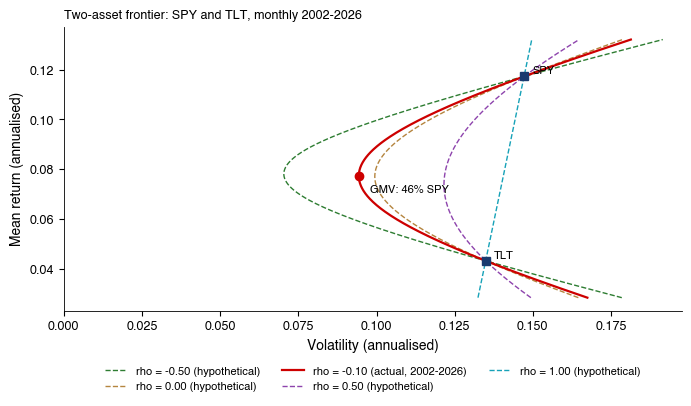

{'mu': {'SPY': 0.1172545143450236, 'TLT': 0.04324046691254241},
 'sd': {'SPY': 0.14718429473277003, 'TLT': 0.13490481664997114},
 'rho': np.float64(-0.10046543983276983),
 'w_gmv': np.float64(0.46050473691596405),
 'sd_gmv': np.float64(0.09433882133723462),
 'mu_gmv': np.float64(0.07732428635352284),
 'T': 288,
 'start': '2002-08-31',
 'end': '2026-07-31'}

In [4]:
def two_asset_stats():
    R, Rex, rf = us_monthly(['SPY', 'TLT'], start='2002-08-01')
    mu = R.mean() * 12
    sd = R.std() * np.sqrt(12)
    rho = R.corr().iloc[0, 1]
    return R, mu, sd, rho


def gmv_two(s1, s2, rho):
    """Ponderea primului activ in GMV cu doua active."""
    return (s2 ** 2 - rho * s1 * s2) / (s1 ** 2 + s2 ** 2 - 2 * rho * s1 * s2)


def fig_two_asset():
    R, mu, sd, rho = two_asset_stats()
    w = np.linspace(-0.2, 1.2, 400)
    fig, ax = plt.subplots(figsize=(7, 4.2))
    for r, c in zip([-0.5, 0.0, rho, 0.5, 1.0], [Forest, Amber, IDAred, Purple, '#17A2B8']):
        m = w * mu['SPY'] + (1 - w) * mu['TLT']
        v = np.sqrt(w ** 2 * sd['SPY'] ** 2 + (1 - w) ** 2 * sd['TLT'] ** 2 + 2 * w * (1 - w) * r * sd['SPY'] * sd['TLT'])
        lab = f'rho = {r:.2f}' + (' (actual, 2002-2026)' if r == rho else ' (hypothetical)')
        ax.plot(v, m, color=c, lw=1.6 if r == rho else 1.0, ls='-' if r == rho else '--', label=lab)
    wg = gmv_two(sd['SPY'], sd['TLT'], rho)
    vg = np.sqrt(wg ** 2 * sd['SPY'] ** 2 + (1 - wg) ** 2 * sd['TLT'] ** 2 + 2 * wg * (1 - wg) * rho * sd['SPY'] * sd['TLT'])
    mg = wg * mu['SPY'] + (1 - wg) * mu['TLT']
    ax.plot(vg, mg, 'o', color=IDAred, ms=6)
    ax.annotate(f'GMV: {wg:.0%} SPY', (vg, mg), xytext=(8, -12), textcoords='offset points', fontsize=8)
    for s in ['SPY', 'TLT']:
        ax.plot(sd[s], mu[s], 's', color=MainBlue, ms=6)
        ax.annotate(s, (sd[s], mu[s]), xytext=(6, 2), textcoords='offset points', fontsize=8)
    ax.set_xlabel('Volatility (annualised)')
    ax.set_ylabel('Mean return (annualised)')
    ax.set_xlim(0, None)
    ax.set_title('Two-asset frontier: SPY and TLT, monthly 2002-2026', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.16)
    plt.tight_layout()
    save_fig('ch4_two_asset')
    return dict(mu=mu.to_dict(), sd=sd.to_dict(), rho=rho, w_gmv=wg, sd_gmv=vg, mu_gmv=mg,
                T=len(R), start=str(R.index[0].date()), end=str(R.index[-1].date()))


fig_two_asset()

## 2. The frontier of US sectors, with and without short sales

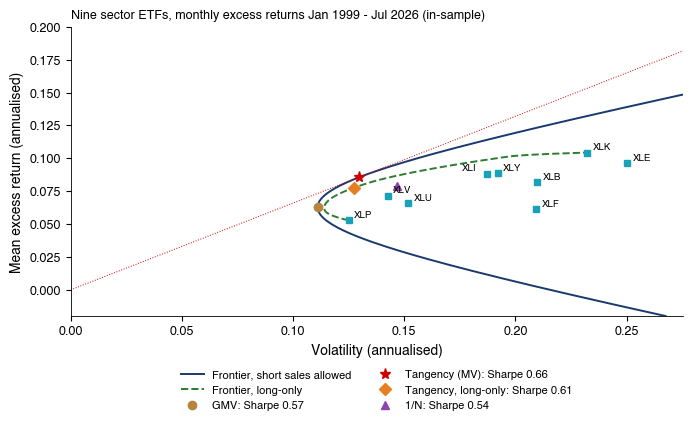

{'T': 331,
 'start': '1999-01-31',
 'end': '2026-07-31',
 'sharpe': {'gmv': np.float64(0.5652960476659711),
  'tan': np.float64(0.6596705337340462),
  'tan_lo': np.float64(0.6094606250329494),
  'ew': np.float64(0.5384938760649349)},
 'w_tan': {'XLB': np.float64(-0.2069641686150686),
  'XLE': np.float64(0.19403983345605622),
  'XLF': np.float64(-0.371793081663628),
  'XLI': np.float64(0.17883525969675615),
  'XLK': np.float64(0.12470334214884742),
  'XLP': np.float64(0.15511577340258262),
  'XLU': np.float64(0.2664941918046142),
  'XLV': np.float64(0.37175702824084067),
  'XLY': np.float64(0.28781182152899937)},
 'w_gmv': {'XLB': np.float64(-0.08596823270686252),
  'XLE': np.float64(0.06732279306549091),
  'XLF': np.float64(-0.05326041987318966),
  'XLI': np.float64(-0.16372096333327404),
  'XLK': np.float64(0.05649942526587134),
  'XLP': np.float64(0.5201175854117274),
  'XLU': np.float64(0.22674970479285878),
  'XLV': np.float64(0.3303152792428897),
  'XLY': np.float64(0.101944828134

In [5]:
def frontier_curve(mu, S, targets):
    """Frontiera analitica (vanzari in lipsa permise): sigma(m) pentru fiecare medie tinta m."""
    Si = np.linalg.inv(S)
    one = np.ones(len(mu))
    A, B, C = one @ Si @ one, one @ Si @ mu, mu @ Si @ mu
    D = A * C - B ** 2
    return np.sqrt((A * targets ** 2 - 2 * B * targets + C) / D)


def frontier_lo(mu, S, targets):
    """Frontiera cu ponderi nenegative (SLSQP), pentru mediile tinta realizabile."""
    n = len(mu)
    out = []
    for m in targets:
        res = minimize(lambda w: w @ S @ w, np.ones(n) / n, method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1},
                                    {'type': 'eq', 'fun': lambda w, m=m: w @ mu - m}])
        out.append(np.sqrt(res.fun) if res.success else np.nan)
    return np.array(out)


def fig_frontier():
    R, Rex, rf = us_monthly(SECTORS)
    mu, S = Rex.mean().values * 12, Rex.cov().values * 12
    t = np.linspace(-0.02, 0.20, 200)
    s_u = frontier_curve(mu, S, t)
    t_lo = np.linspace(mu.min(), mu.max(), 60)
    s_lo = frontier_lo(mu, S, t_lo)
    wg, wt, wtl = w_gmv(S), w_tan(mu, S), w_long_only(S, mu)
    pt = lambda w: (np.sqrt(w @ S @ w), w @ mu)
    fig, ax = plt.subplots(figsize=(7, 4.4))
    ax.plot(s_u, t, color=MainBlue, lw=1.4, label='Frontier, short sales allowed')
    ax.plot(s_lo, t_lo, color=Forest, lw=1.4, ls='--', label='Frontier, long-only')
    for k, s in enumerate(SECTORS):
        ax.plot(np.sqrt(S[k, k]), mu[k], 's', color='#17A2B8', ms=4)
        ax.annotate(s, (np.sqrt(S[k, k]), mu[k]), xytext=(-18, 3) if s == 'XLI' else (4, 2),
                    textcoords='offset points', fontsize=7)
    for w, lab, c, mk in [(wg, 'GMV', Amber, 'o'), (wt, 'Tangency (MV)', IDAred, '*'),
                          (wtl, 'Tangency, long-only', Orange, 'D'), (w_ew(9), '1/N', Purple, '^')]:
        x, y = pt(w)
        ax.plot(x, y, mk, color=c, ms=8 if mk == '*' else 6, label=f'{lab}: Sharpe {y / x:.2f}')
    sm = max(np.sqrt(np.diag(S)).max(), pt(wt)[0]) * 1.1
    ax.plot([0, sm], [0, sm * pt(wt)[1] / pt(wt)[0]], color=IDAred, lw=0.7, ls=':')
    ax.set_xlim(0, sm)
    ax.set_ylim(-0.02, 0.2)
    ax.set_xlabel('Volatility (annualised)')
    ax.set_ylabel('Mean excess return (annualised)')
    ax.set_title(f'Nine sector ETFs, monthly excess returns {Rex.index[0]:%b %Y} - {Rex.index[-1]:%b %Y} (in-sample)',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save_fig('ch4_frontier')
    sr = lambda w: pt(w)[1] / pt(w)[0]
    return dict(T=len(Rex), start=str(Rex.index[0].date()), end=str(Rex.index[-1].date()),
                sharpe=dict(gmv=sr(wg), tan=sr(wt), tan_lo=sr(wtl), ew=sr(w_ew(9))),
                w_tan=dict(zip(SECTORS, wt)), w_gmv=dict(zip(SECTORS, wg)), w_tan_lo=dict(zip(SECTORS, wtl)),
                gmv_vol=pt(wg)[0], mu=dict(zip(SECTORS, mu)), vol=dict(zip(SECTORS, np.sqrt(np.diag(S)))))


fig_frontier()

## 3. The limits of Markowitz: estimation error and the 1/N benchmark

- Simulations with the sector sample moments as true parameters; returns from the Normal distribution.

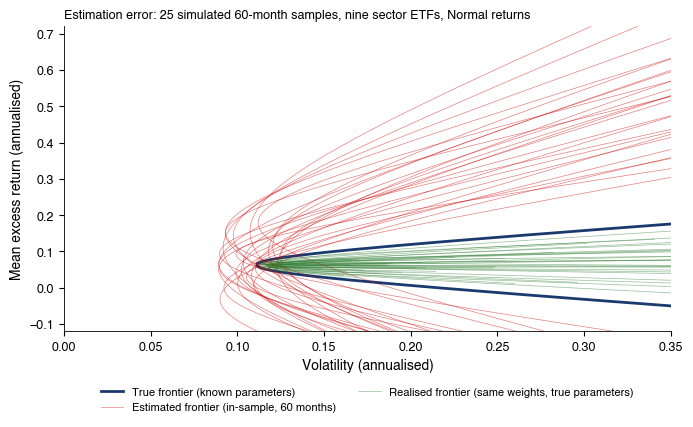

{'T': 60,
 'nsim': 2000,
 'sr_opt': np.float64(0.6596705337340462),
 'sr_ew': np.float64(0.5384938760649349),
 'est_sr_median': 1.5646225225130446,
 'true_sr_median': 0.2999619323802991,
 'share_true_below_ew': 0.9625,
 'share_true_neg': 0.0755}

In [6]:
def sector_truth():
    """Parametrii 'adevarati' ai simularilor: media si covarianta lunara din tot esantionul."""
    R, Rex, rf = us_monthly(SECTORS)
    return Rex.mean().values, Rex.cov().values


def fig_estimation_error(T=60, nsim=25, seed=SEED):
    mu, S = sector_truth()
    rng = np.random.default_rng(seed)
    t = np.linspace(-0.01, 0.06, 150) / 1          # medii lunare tinta
    fig, ax = plt.subplots(figsize=(7, 4.4))
    s_true = frontier_curve(mu, S, t)
    ax.plot(s_true * np.sqrt(12), t * 12, color=MainBlue, lw=2, label='True frontier (known parameters)')
    est_sr, true_sr = [], []
    for k in range(nsim):
        X = rng.multivariate_normal(mu, S, T)
        m_hat, S_hat = X.mean(0), np.cov(X.T)
        Si = np.linalg.inv(S_hat)
        one = np.ones(len(mu))
        s_hat = frontier_curve(m_hat, S_hat, t)
        # portofoliile frontierei estimate, evaluate cu parametrii adevarati
        A, B, C = one @ Si @ one, one @ Si @ m_hat, m_hat @ Si @ m_hat
        D = A * C - B ** 2
        real_m, real_s = [], []
        for m in t:
            lam, gam = (C - m * B) / D, (m * A - B) / D
            w = Si @ (lam * one + gam * m_hat)
            real_m.append(w @ mu)
            real_s.append(np.sqrt(w @ S @ w))
        ax.plot(s_hat * np.sqrt(12), t * 12, color=IDAred, lw=0.5, alpha=0.5,
                label='Estimated frontier (in-sample, 60 months)' if k == 0 else None)
        ax.plot(np.array(real_s) * np.sqrt(12), np.array(real_m) * 12, color=Forest, lw=0.5, alpha=0.5,
                label='Realised frontier (same weights, true parameters)' if k == 0 else None)
    for k in range(2000):
        X = rng.multivariate_normal(mu, S, T)
        m_hat, S_hat = X.mean(0), np.cov(X.T)
        w = w_tan(m_hat, S_hat)
        est_sr.append((w @ m_hat) / np.sqrt(w @ S_hat @ w) * np.sqrt(12))
        true_sr.append((w @ mu) / np.sqrt(w @ S @ w) * np.sqrt(12))
    wt = w_tan(mu, S)
    sr_opt = (wt @ mu) / np.sqrt(wt @ S @ wt) * np.sqrt(12)
    we = w_ew(len(mu))
    sr_ew = (we @ mu) / np.sqrt(we @ S @ we) * np.sqrt(12)
    ax.set_xlim(0, 0.35)
    ax.set_ylim(-0.12, 0.72)
    ax.set_xlabel('Volatility (annualised)')
    ax.set_ylabel('Mean excess return (annualised)')
    ax.set_title('Estimation error: 25 simulated 60-month samples, nine sector ETFs, Normal returns',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save_fig('ch4_estimation_error')
    est_sr, true_sr = np.abs(np.array(est_sr)), np.array(true_sr)
    return dict(T=T, nsim=2000, sr_opt=sr_opt, sr_ew=sr_ew,
                est_sr_median=float(np.median(est_sr)), true_sr_median=float(np.median(true_sr)),
                share_true_below_ew=float(np.mean(true_sr < sr_ew)), share_true_neg=float(np.mean(true_sr < 0)))


fig_estimation_error()

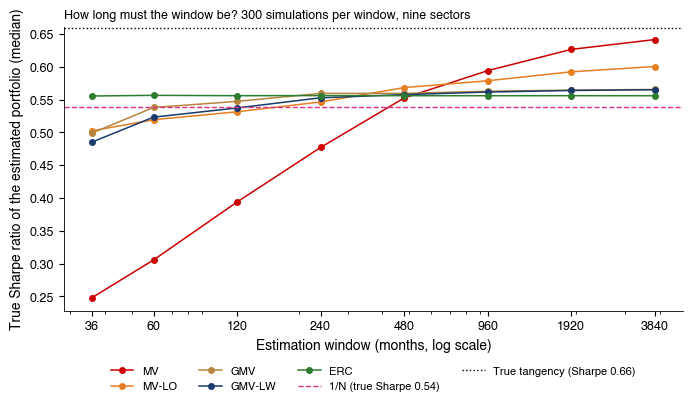

{'Ts': [36, 60, 120, 240, 480, 960, 1920, 3840],
 'median_true_sr': {'MV': {'36': np.float64(0.24820236261009215),
   '60': np.float64(0.30559684205007276),
   '120': np.float64(0.393919095995256),
   '240': np.float64(0.4770517531790528),
   '480': np.float64(0.5524062447451136),
   '960': np.float64(0.593993144689862),
   '1920': np.float64(0.6263801986203466),
   '3840': np.float64(0.6413536251409315)},
  'MV-LO': {'36': np.float64(0.5022293749402433),
   '60': np.float64(0.5192180070776619),
   '120': np.float64(0.5313480695110653),
   '240': np.float64(0.546300250398492),
   '480': np.float64(0.5681859392807012),
   '960': np.float64(0.5785817083110698),
   '1920': np.float64(0.5922267574796061),
   '3840': np.float64(0.6002874469219)},
  'GMV': {'36': np.float64(0.49887235657428697),
   '60': np.float64(0.5378984250888984),
   '120': np.float64(0.5471780851634146),
   '240': np.float64(0.5594014576368116),
   '480': np.float64(0.5593293784370212),
   '960': np.float64(0.562664383

In [7]:
def fig_window_length(nsim=300, seed=SEED):
    mu, S = sector_truth()
    n = len(mu)
    rng = np.random.default_rng(seed)
    Ts = [36, 60, 120, 240, 480, 960, 1920, 3840]
    names = ['MV', 'MV-LO', 'GMV', 'GMV-LW', 'ERC']
    res = {k: [] for k in names}
    true_sr = lambda w: (w @ mu) / np.sqrt(w @ S @ w) * np.sqrt(12)
    for T in Ts:
        vals = {k: [] for k in names}
        for i in range(nsim):
            X = rng.multivariate_normal(mu, S, T)
            for k in names:
                vals[k].append(true_sr(weights(k, X)))
        for k in names:
            res[k].append(np.median(vals[k]))
    sr_ew = true_sr(w_ew(n))
    sr_opt = true_sr(w_tan(mu, S))
    fig, ax = plt.subplots(figsize=(7, 4.2))
    for k in names:
        ax.plot(Ts, res[k], 'o-', color=SCOL[k], ms=4, label=k)
    ax.axhline(sr_ew, color=EWcol, ls='--', lw=1, label=f'1/N (true Sharpe {sr_ew:.2f})')
    ax.axhline(sr_opt, color='black', ls=':', lw=1, label=f'True tangency (Sharpe {sr_opt:.2f})')
    ax.set_xscale('log')
    ax.set_xticks(Ts, [str(T) for T in Ts])
    ax.set_xlabel('Estimation window (months, log scale)')
    ax.set_ylabel('True Sharpe ratio of the estimated portfolio (median)')
    ax.set_title(f'How long must the window be? {nsim} simulations per window, nine sectors', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.16)
    plt.tight_layout()
    save_fig('ch4_window_length')
    cross = next((T for T, v in zip(Ts, res['MV']) if v > sr_ew), None)
    return dict(Ts=Ts, median_true_sr={k: dict(zip(map(str, Ts), v)) for k, v in res.items()},
                sr_ew=sr_ew, sr_opt=sr_opt, mv_beats_ew_at=cross)


fig_window_length(nsim=300)

## 4. Covariance shrinkage (Ledoit–Wolf)

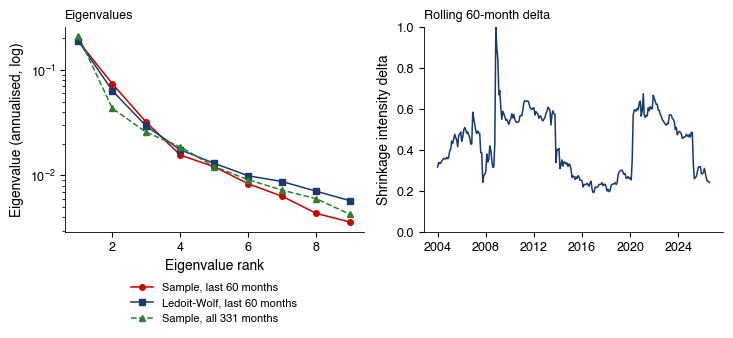

{'delta_last': np.float64(0.23984627231136196),
 'delta_mean': np.float64(0.43295242844134224),
 'delta_min': 0.19061562037268706,
 'delta_max': 1.0,
 'cond_sample': np.float64(51.59165848731628),
 'cond_lw': np.float64(32.46524707484896),
 'cond_full': np.float64(48.70864588697877),
 'ev_sample': [0.18610017403498463,
  0.07347968865066128,
  0.03177592599516837,
  0.015575847731240348,
  0.012067658064428171,
  0.008330621415441,
  0.006337858086958281,
  0.004376076253975444,
  0.003607175646054035],
 'ev_lw': [0.187086808132558,
  0.06331912705294206,
  0.029244161503560722,
  0.017486658738232286,
  0.013010035738811623,
  0.009911476132074024,
  0.008745761065985215,
  0.007084318188721737,
  0.005762679326025985],
 'ev_full': [0.2080462025103107,
  0.04308549059878002,
  0.025573136718565773,
  0.01866025767070133,
  0.012107258728035449,
  0.009098799458153934,
  0.007245634008769222,
  0.00601938201325471,
  0.00427123765651483],
 'end': '2026-07-31'}

In [8]:
def fig_shrinkage():
    R, Rex, rf = us_monthly(SECTORS)
    X = Rex.values
    last = X[-WINDOW:]
    S = np.cov(last.T, bias=True)
    Slw, d_last = lw_cc(last)
    Sfull = np.cov(X.T, bias=True)
    ev = lambda A: np.sort(np.linalg.eigvalsh(A))[::-1] * 12
    deltas = pd.Series([lw_cc(X[t - WINDOW:t])[1] for t in range(WINDOW, len(X) + 1)],
                       index=Rex.index[WINDOW - 1:])
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))
    k = np.arange(1, 10)
    axes[0].plot(k, ev(S), 'o-', color=IDAred, ms=4, label='Sample, last 60 months')
    axes[0].plot(k, ev(Slw), 's-', color=MainBlue, ms=4, label='Ledoit-Wolf, last 60 months')
    axes[0].plot(k, ev(Sfull), '^--', color=Forest, ms=4, label=f'Sample, all {len(X)} months')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Eigenvalue rank')
    axes[0].set_ylabel('Eigenvalue (annualised, log)')
    axes[0].set_title('Eigenvalues', fontsize=9, loc='left')
    legend_outside_bottom(axes[0], ncol=1, y=-0.2)
    axes[1].plot(deltas.index, deltas.values, color=MainBlue)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('Shrinkage intensity delta')
    axes[1].set_title('Rolling 60-month delta', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch4_shrinkage')
    cond = lambda A: np.linalg.cond(A)
    return dict(delta_last=d_last, delta_mean=deltas.mean(), delta_min=deltas.min(), delta_max=deltas.max(),
                cond_sample=cond(S), cond_lw=cond(Slw), cond_full=cond(Sfull),
                ev_sample=ev(S).tolist(), ev_lw=ev(Slw).tolist(), ev_full=ev(Sfull).tolist(),
                end=str(Rex.index[-1].date()))


fig_shrinkage()

## 5. Black–Litterman: one relative view on sectors

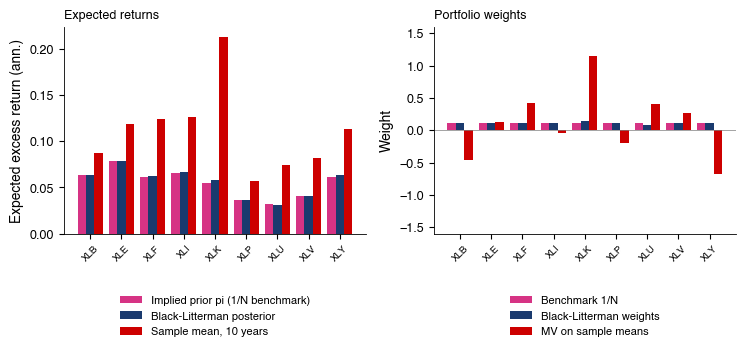

{'start': '2016-08-31',
 'end': '2026-07-31',
 'T': 120,
 'delta': 2.5,
 'tau': 0.05,
 'view': 'XLK - XLU = 3% p.a.',
 'prior_view': 0.02218123990657088,
 'post_view': 0.026090619953285432,
 'pi': {'XLB': np.float64(0.0629260312301894),
  'XLE': np.float64(0.07823924037050137),
  'XLF': np.float64(0.061516929771488794),
  'XLI': np.float64(0.06518624437079529),
  'XLK': np.float64(0.05475265838040866),
  'XLP': np.float64(0.036066479631737515),
  'XLU': np.float64(0.03257141847383778),
  'XLV': np.float64(0.04032569268360592),
  'XLY': np.float64(0.06150130690056855)},
 'mu_bl': {'XLB': np.float64(0.06347035965045082),
  'XLE': np.float64(0.07874395907333276),
  'XLF': np.float64(0.06242311595208663),
  'XLI': np.float64(0.06612430976935126),
  'XLK': np.float64(0.05753403594804175),
  'XLP': np.float64(0.03593120847665053),
  'XLU': np.float64(0.031443415994756314),
  'XLV': np.float64(0.04062297757492034),
  'XLY': np.float64(0.06334067599888832)},
 'mu_sample': {'XLB': np.float64(0.

In [9]:
def black_litterman(Sigma, w_b, P, q, delta=2.5, tau=0.05, conf=None):
    """Black-Litterman (1992), forma He-Litterman: Omega = diag(P tau Sigma P') daca nu e data."""
    pi = delta * Sigma @ w_b
    Om = np.diag(np.diag(P @ (tau * Sigma) @ P.T)) if conf is None else conf
    A = np.linalg.inv(tau * Sigma) + P.T @ np.linalg.inv(Om) @ P
    mu_bl = np.linalg.solve(A, np.linalg.inv(tau * Sigma) @ pi + P.T @ np.linalg.inv(Om) @ q)
    w_bl = np.linalg.solve(delta * Sigma, mu_bl)
    return pi, mu_bl, w_bl


def fig_black_litterman():
    R, Rex, rf = us_monthly(SECTORS, start='2016-08-01')
    Sigma = Rex.cov().values * 12
    n = len(SECTORS)
    w_b = w_ew(n)
    P = np.zeros((1, n))
    P[0, SECTORS.index('XLK')], P[0, SECTORS.index('XLU')] = 1, -1
    q = np.array([0.03])
    pi, mu_bl, w_bl = black_litterman(Sigma, w_b, P, q)
    mu_s = Rex.mean().values * 12
    w_s = w_tan(mu_s, Sigma)
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8))
    x = np.arange(n)
    axes[0].bar(x - 0.27, pi, 0.27, color=EWcol, label='Implied prior pi (1/N benchmark)')
    axes[0].bar(x, mu_bl, 0.27, color=MainBlue, label='Black-Litterman posterior')
    axes[0].bar(x + 0.27, mu_s, 0.27, color=IDAred, label='Sample mean, 10 years')
    axes[0].set_xticks(x, SECTORS, rotation=45, fontsize=7)
    axes[0].set_ylabel('Expected excess return (ann.)')
    axes[0].set_title('Expected returns', fontsize=9, loc='left')
    legend_outside_bottom(axes[0], ncol=1, y=-0.25)
    axes[1].bar(x - 0.27, w_b, 0.27, color=EWcol, label='Benchmark 1/N')
    axes[1].bar(x, w_bl, 0.27, color=MainBlue, label='Black-Litterman weights')
    axes[1].bar(x + 0.27, w_s, 0.27, color=IDAred, label='MV on sample means')
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_xticks(x, SECTORS, rotation=45, fontsize=7)
    axes[1].set_ylim(-1.6, 1.6)
    axes[1].set_ylabel('Weight')
    axes[1].set_title('Portfolio weights', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=1, y=-0.25)
    plt.tight_layout()
    save_fig('ch4_black_litterman')
    return dict(start=str(Rex.index[0].date()), end=str(Rex.index[-1].date()), T=len(Rex), delta=2.5, tau=0.05,
                view='XLK - XLU = 3% p.a.', prior_view=float(P @ pi), post_view=float(P @ mu_bl),
                pi=dict(zip(SECTORS, pi)), mu_bl=dict(zip(SECTORS, mu_bl)), mu_sample=dict(zip(SECTORS, mu_s)),
                w_bl=dict(zip(SECTORS, w_bl)), w_sample_mv=dict(zip(SECTORS, w_s)),
                w_bl_sum=float(w_bl.sum()))


fig_black_litterman()

## 6. Risk parity and Hierarchical Risk Parity

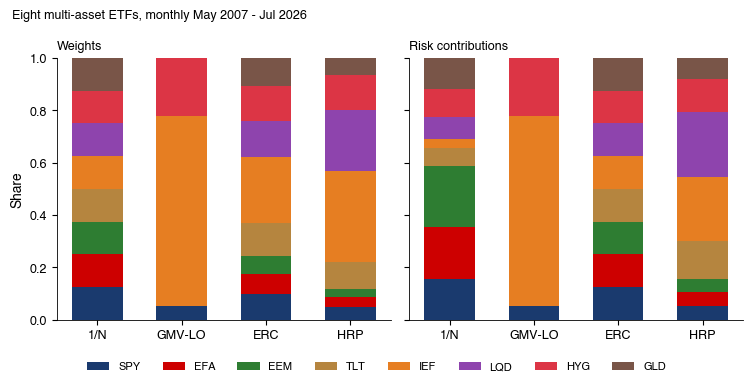

{'1/N': {'w': {'SPY': np.float64(0.125),
   'EFA': np.float64(0.125),
   'EEM': np.float64(0.125),
   'TLT': np.float64(0.125),
   'IEF': np.float64(0.125),
   'LQD': np.float64(0.125),
   'HYG': np.float64(0.125),
   'GLD': np.float64(0.125)},
  'rc': {'SPY': np.float64(0.15742401677889428),
   'EFA': np.float64(0.19496263503006858),
   'EEM': np.float64(0.23418951897865534),
   'TLT': np.float64(0.06788552619819219),
   'IEF': np.float64(0.03553673033247813),
   'LQD': np.float64(0.08600817929053724),
   'HYG': np.float64(0.10670428542809304),
   'GLD': np.float64(0.11728910796308115)},
  'vol': 0.09417785644005897,
  'rc_equity': 0.6932804562157113},
 'GMV-LO': {'w': {'SPY': np.float64(0.05196143603153195),
   'EFA': np.float64(0.0),
   'EEM': np.float64(1.013354109004409e-18),
   'TLT': np.float64(6.482788333378806e-17),
   'IEF': np.float64(0.7259336380626622),
   'LQD': np.float64(6.773757097955044e-17),
   'HYG': np.float64(0.22210492590580558),
   'GLD': np.float64(4.4229287002

In [10]:
def fig_risk_contrib():
    R, Rex, rf = us_monthly(MULTI)
    S = Rex.cov().values * 12
    ws = {'1/N': w_ew(len(MULTI)), 'GMV-LO': w_long_only(S), 'ERC': w_erc(S), 'HRP': w_hrp(S)}
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8), sharey=True)
    for ax, what in zip(axes, ['Weights', 'Risk contributions']):
        bottom = np.zeros(len(ws))
        for k, a in enumerate(MULTI):
            vals = np.array([w[k] if what == 'Weights' else risk_contrib(w, S)[k] for w in ws.values()])
            ax.bar(list(ws), vals, bottom=bottom, color=PALETTE[k], label=a, width=0.6)
            bottom += vals
        ax.set_title(what, fontsize=9, loc='left')
        ax.set_ylim(0, 1)
    axes[0].set_ylabel('Share')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=8, frameon=False)
    plt.suptitle(f'Eight multi-asset ETFs, monthly {Rex.index[0]:%b %Y} - {Rex.index[-1]:%b %Y}', fontsize=9, x=0.02, ha='left')
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    save_fig('ch4_risk_contrib')
    out = {}
    for k, w in ws.items():
        rc = risk_contrib(w, S)
        out[k] = dict(w=dict(zip(MULTI, w)), rc=dict(zip(MULTI, rc)), vol=float(np.sqrt(w @ S @ w)),
                      rc_equity=float(rc[:3].sum() + rc[MULTI.index('HYG')]))
    out['vol'] = dict(zip(MULTI, np.sqrt(np.diag(S))))
    out['T'] = len(Rex)
    return out


fig_risk_contrib()

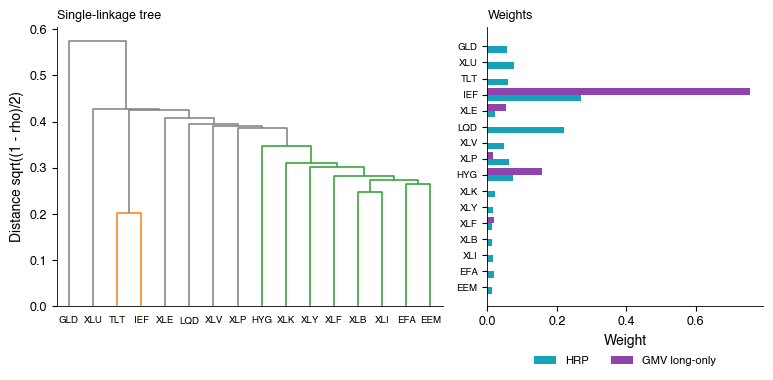

{'order': ['GLD',
  'XLU',
  'TLT',
  'IEF',
  'XLE',
  'LQD',
  'XLV',
  'XLP',
  'HYG',
  'XLK',
  'XLY',
  'XLF',
  'XLB',
  'XLI',
  'EFA',
  'EEM'],
 'w_hrp': {'XLB': np.float64(0.0140828251540641),
  'XLE': np.float64(0.020927144144662853),
  'XLF': np.float64(0.013266790832320952),
  'XLI': np.float64(0.015795340880039668),
  'XLK': np.float64(0.020542353481381805),
  'XLP': np.float64(0.06263613393781442),
  'XLU': np.float64(0.07654735119668661),
  'XLV': np.float64(0.04764600380621508),
  'XLY': np.float64(0.017388409349698708),
  'EFA': np.float64(0.019902670972491154),
  'EEM': np.float64(0.013543495425983583),
  'TLT': np.float64(0.06021027324946132),
  'IEF': np.float64(0.2681090558895407),
  'LQD': np.float64(0.21911728142548165),
  'HYG': np.float64(0.0747678776203133),
  'GLD': np.float64(0.05551699263384427)},
 'w_gmv_lo': {'XLB': np.float64(0.0),
  'XLE': np.float64(0.053314454613904515),
  'XLF': np.float64(0.018621917961084276),
  'XLI': np.float64(0.0),
  'XLK': n

In [11]:
def fig_hrp():
    R, Rex, rf = us_monthly(COMBINED)
    S = Rex.cov().values * 12
    Z = hrp_tree(S)
    w = w_hrp(S)
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.9), gridspec_kw={'width_ratios': [1.4, 1]})
    dn = dendrogram(Z, labels=COMBINED, ax=axes[0], color_threshold=0.35, above_threshold_color=Gray,
                    leaf_font_size=7)
    axes[0].set_ylabel('Distance sqrt((1 - rho)/2)')
    axes[0].set_title('Single-linkage tree', fontsize=9, loc='left')
    order = dn['ivl']
    wi = pd.Series(w, index=COMBINED)[order]
    wg = pd.Series(w_long_only(S), index=COMBINED)[order]
    y = np.arange(len(order))
    axes[1].barh(y + 0.2, wi.values, 0.4, color='#17A2B8', label='HRP')
    axes[1].barh(y - 0.2, wg.values, 0.4, color=Purple, label='GMV long-only')
    axes[1].set_yticks(y, order, fontsize=7)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Weight')
    axes[1].set_title('Weights', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=2, y=-0.14)
    plt.tight_layout()
    save_fig('ch4_hrp')
    return dict(order=order, w_hrp=dict(zip(COMBINED, w)), w_gmv_lo=dict(zip(COMBINED, w_long_only(S))),
                n_nonzero_gmv_lo=int((w_long_only(S) > 1e-4).sum()), T=len(Rex),
                start=str(Rex.index[0].date()))


fig_hrp()

## 7. Out-of-sample evaluation on three universes

- Sectors: OOS January 2004 – July 2026; multi-asset and combined: May 2012 – July 2026.

In [12]:
def run_backtests():
    out = {}
    for name, syms in UNIVERSES.items():
        R, Rex, rf = us_monthly(syms)
        out[name] = backtest(R, Rex)
        print(f'   backtest {name}: {len(out[name][0])} months')
    return out


bts = run_backtests()
tabs = {}
for u, (ret, to, W) in bts.items():
    t = summary(ret, to)
    t.attrs = dict(start=f'{ret.index[0]:%Y-%m}', end=f'{ret.index[-1]:%Y-%m}')
    tabs[u] = t
    print(u, t.attrs)
    print(t.round(3), '\n')

   backtest Sectors: 271 months


   backtest Multi-asset: 171 months


   backtest Combined: 171 months
Sectors {'start': '2004-01', 'end': '2026-07'}
         mean    vol  sharpe  turnover    mdd  sharpe_10bp  sharpe_50bp
1/N     0.094  0.143   0.661     0.024 -0.503        0.659        0.651
MV      0.178  0.690   0.258     3.855 -1.000        0.194       -0.080
MV-LO   0.107  0.147   0.724     0.235 -0.436        0.705        0.629
GMV     0.085  0.119   0.711     0.234 -0.338        0.687        0.594
GMV-LO  0.081  0.115   0.700     0.087 -0.356        0.691        0.654
GMV-LW  0.076  0.118   0.645     0.137 -0.324        0.632        0.576
ERC     0.093  0.132   0.699     0.028 -0.479        0.696        0.686
HRP     0.090  0.125   0.719     0.081 -0.448        0.711        0.679 

Multi-asset {'start': '2012-05', 'end': '2026-07'}
         mean    vol  sharpe  turnover    mdd  sharpe_10bp  sharpe_50bp
1/N     0.043  0.084   0.518     0.020 -0.219        0.515        0.504
MV     -1.130  5.175  -0.218    44.464 -1.000       -0.303       -0.537
MV-

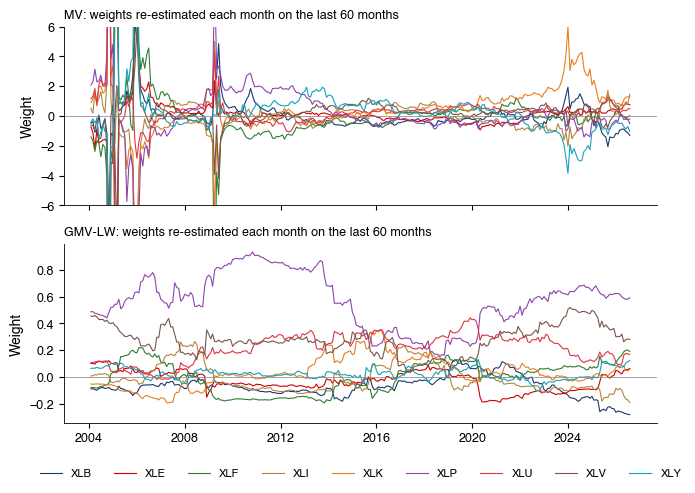

{'mv_max_abs': 26.0760979999006, 'mv_median_gross': 4.864174574317517, 'lw_max_abs': 0.9355751986853494, 'lw_median_gross': 1.5016997528604783, 'mv_share_months_gross_gt3': 0.9040590405904059}


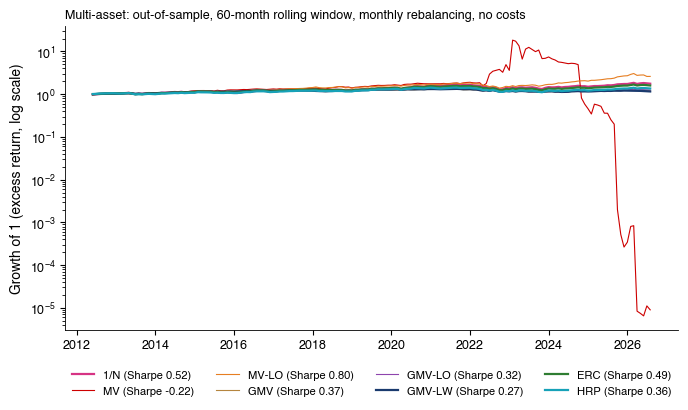

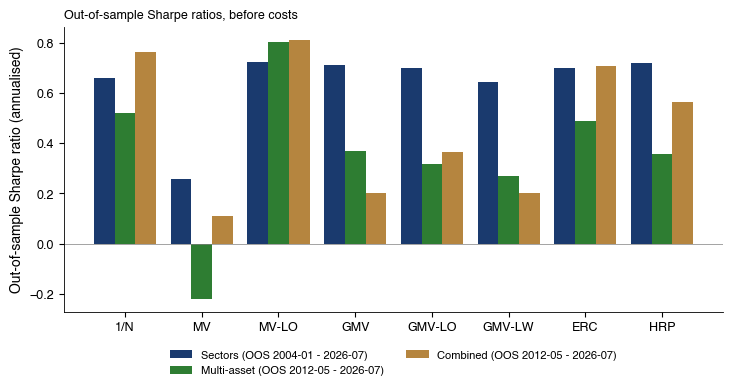

In [13]:
def fig_rolling_weights(bt):
    ret, to, W = bt
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 5.0), sharex=True)
    for ax, s in zip(axes, ['MV', 'GMV-LW']):
        for k, c in enumerate(W[s].columns):
            ax.plot(W[s].index, W[s][c], color=PALETTE[k % len(PALETTE)], lw=0.8, label=c)
        ax.axhline(0, color=Gray, lw=0.5)
        ax.set_ylabel('Weight')
        ax.set_title(f'{s}: weights re-estimated each month on the last 60 months', fontsize=9, loc='left')
    axes[0].set_ylim(-6, 6)
    legend_outside_bottom(axes[1], ncol=9, y=-0.2)
    plt.tight_layout()
    save_fig('ch4_rolling_weights')
    mv, lw = W['MV'], W['GMV-LW']
    return dict(mv_max_abs=float(mv.abs().max().max()), mv_median_gross=float(mv.abs().sum(1).median()),
                lw_max_abs=float(lw.abs().max().max()), lw_median_gross=float(lw.abs().sum(1).median()),
                mv_share_months_gross_gt3=float((mv.abs().sum(1) > 3).mean()))


def fig_oos_cum(bts, universe='Multi-asset'):
    ret, to, W = bts[universe]
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for s in STRATS:
        wealth = np.cumprod(1 + ret[s].clip(lower=-0.99))
        ax.plot(ret.index, wealth, color=SCOL[s], lw=1.6 if s in ('1/N', 'GMV-LW', 'ERC', 'HRP') else 0.8,
                label=f'{s} (Sharpe {sharpe(ret[s]):.2f})')
    ax.set_yscale('log')
    ax.set_ylabel('Growth of 1 (excess return, log scale)')
    ax.set_title(f'{universe}: out-of-sample, 60-month rolling window, monthly rebalancing, no costs',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.1)
    plt.tight_layout()
    save_fig('ch4_oos_cum')


def fig_oos_sharpe(tabs):
    fig, ax = plt.subplots(figsize=(7.4, 4.0))
    x = np.arange(len(STRATS))
    wd = 0.27
    for k, (u, c) in enumerate(zip(UNIVERSES, [MainBlue, Forest, Amber])):
        v = tabs[u].loc[STRATS, 'sharpe'].values
        ax.bar(x + (k - 1) * wd, v, wd, color=c, label=f'{u} (OOS {tabs[u].attrs["start"]} - {tabs[u].attrs["end"]})')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(x, STRATS)
    ax.set_ylabel('Out-of-sample Sharpe ratio (annualised)')
    ax.set_title('Out-of-sample Sharpe ratios, before costs', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    plt.tight_layout()
    save_fig('ch4_oos_sharpe')


print(fig_rolling_weights(bts['Sectors']))
fig_oos_cum(bts)
fig_oos_sharpe(tabs)

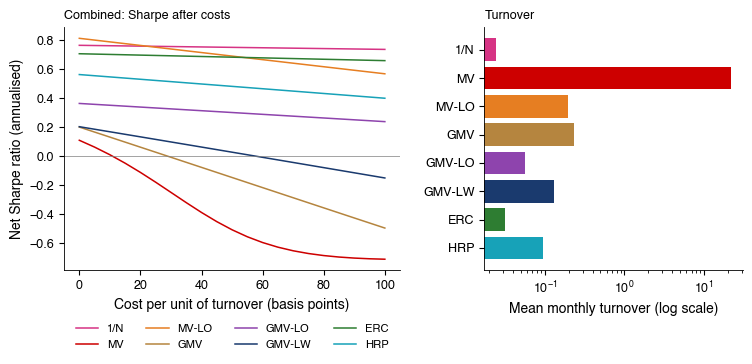

In [14]:
def fig_costs(bts, universe='Combined'):
    ret, to, W = bts[universe]
    c = np.arange(0, 101, 5)
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8), gridspec_kw={'width_ratios': [1.3, 1]})
    for s in STRATS:
        axes[0].plot(c, [sharpe(ret[s] - cc / 1e4 * to[s].fillna(0)) for cc in c], color=SCOL[s], label=s)
    axes[0].set_xlabel('Cost per unit of turnover (basis points)')
    axes[0].set_ylabel('Net Sharpe ratio (annualised)')
    axes[0].set_title(f'{universe}: Sharpe after costs', fontsize=9, loc='left')
    axes[0].axhline(0, color=Gray, lw=0.5)
    legend_outside_bottom(axes[0], ncol=4, y=-0.18)
    tv = to[STRATS].mean()
    axes[1].barh(STRATS, tv.values, color=[SCOL[s] for s in STRATS])
    axes[1].set_xscale('log')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Mean monthly turnover (log scale)')
    axes[1].set_title('Turnover', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch4_costs')


fig_costs(bts)

Sectors
            diff     p_hac  p_boot
MV     -0.403892  0.222775  0.2135
MV-LO   0.063438  0.597287  0.6115
GMV     0.049864  0.754264    0.75
GMV-LO   0.03939  0.725619  0.7285
GMV-LW -0.015361  0.926182  0.9275
ERC     0.038131  0.091479  0.0995
HRP     0.058521  0.192688  0.2025 

Multi-asset
            diff     p_hac  p_boot
MV     -0.738817  0.013769   0.061
MV-LO    0.28629  0.118859    0.12
GMV    -0.148347  0.510861   0.533
GMV-LO -0.202461  0.140073  0.1445
GMV-LW -0.247891  0.194414   0.211
ERC    -0.030713  0.611606   0.591
HRP    -0.161871  0.065371  0.0675 

Combined
            diff     p_hac  p_boot
MV     -0.656211  0.064812  0.1265
MV-LO   0.048453  0.817477   0.828
GMV    -0.564851  0.030374   0.033
GMV-LO -0.401688  0.047657  0.0475
GMV-LW  -0.56241   0.02376  0.0255
ERC    -0.058166  0.610771  0.6125
HRP    -0.202023  0.169294   0.169 



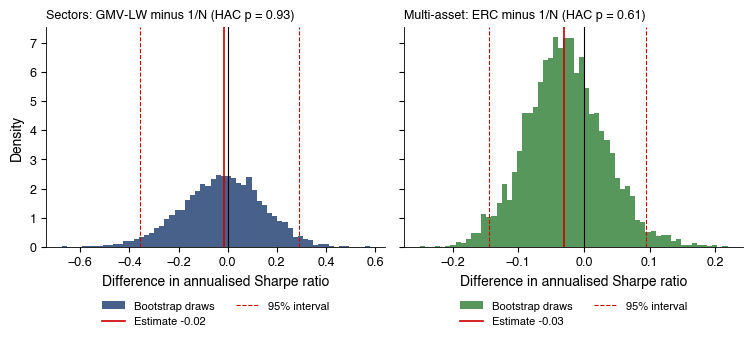

{'Sectors': {'strategy': 'GMV-LW',
  'diff': np.float64(-0.015332946266208403),
  'ci': [-0.35594494377127234, 0.28965136690127247],
  'p_boot': np.float64(0.9262),
  'se_hac': np.float64(0.16580004404044116),
  'p_hac': np.float64(0.9261819064106698)},
 'Multi-asset': {'strategy': 'ERC',
  'diff': np.float64(-0.0306233933968304),
  'ci': [-0.1447115932397852, 0.09394362245574932],
  'p_boot': np.float64(0.5894),
  'se_hac': np.float64(0.060485265878214546),
  'p_hac': np.float64(0.6116062245569931)}}

In [15]:
def sharpe_tests(bts, bench='1/N'):
    out = {}
    for u, (ret, to, W) in bts.items():
        out[u] = {}
        for s in STRATS:
            if s == bench:
                continue
            d, se, p = sr_diff_hac(ret[s], ret[bench])
            db, ci, pb, _ = sr_diff_boot(ret[s], ret[bench], B=2000)
            out[u][s] = dict(diff=d, se_hac=se, p_hac=p, ci_boot=ci.tolist(), p_boot=pb)
    return out


def fig_sharpe_test(bts):
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6), sharey=True)
    res = {}
    for ax, (u, s) in zip(axes, [('Sectors', 'GMV-LW'), ('Multi-asset', 'ERC')]):
        ret = bts[u][0]
        d, ci, p, draws = sr_diff_boot(ret[s], ret['1/N'])
        dh, se, ph = sr_diff_hac(ret[s], ret['1/N'])
        ax.hist(draws, bins=60, color=SCOL[s], alpha=0.8, density=True, label='Bootstrap draws')
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(d, color=IDAred, lw=1.2, label=f'Estimate {d:+.2f}')
        ax.axvline(ci[0], color=IDAred, ls='--', lw=0.8, label='95% interval')
        ax.axvline(ci[1], color=IDAred, ls='--', lw=0.8)
        ax.set_title(f'{u}: {s} minus 1/N (HAC p = {ph:.2f})', fontsize=9, loc='left')
        ax.set_xlabel('Difference in annualised Sharpe ratio')
        legend_outside_bottom(ax, ncol=2, y=-0.2)
        res[u] = dict(strategy=s, diff=d, ci=ci.tolist(), p_boot=p, se_hac=se, p_hac=ph)
    axes[0].set_ylabel('Density')
    plt.tight_layout()
    save_fig('ch4_sharpe_test')
    return res


for u, d in sharpe_tests(bts).items():
    print(u)
    print(pd.DataFrame(d).T[['diff', 'p_hac', 'p_boot']].round(3), '\n')
fig_sharpe_test(bts)

## 8. A portfolio of BVB blue chips (RON)

- 36-month window; benchmarks BET-TR and BET; Sharpe ratios with $R_f = 0$.

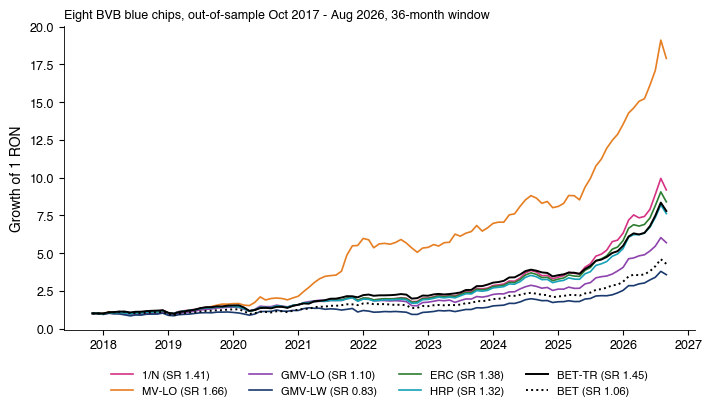

         mean    vol  sharpe  turnover    mdd  sharpe_10bp  sharpe_50bp
1/N     0.269  0.191   1.408     0.039 -0.230        1.406        1.396
MV-LO   0.349  0.210   1.661     0.163 -0.202        1.651        1.612
GMV-LO  0.215  0.196   1.098     0.196 -0.283        1.086        1.038
GMV-LW  0.163  0.197   0.826     0.174 -0.321        0.815        0.773
ERC     0.258  0.188   1.375     0.050 -0.219        1.372        1.360
HRP     0.247  0.187   1.322     0.101 -0.218        1.316        1.291
BET-TR  0.247  0.170   1.449     0.000 -0.240        1.449        1.449
BET     0.178  0.168   1.065     0.000 -0.240        1.065        1.065
            diff     p_hac                                      ci_boot  \
1/N     -0.04167  0.766692  [-0.40572983669663854, 0.19073462303978528]   
MV-LO   0.212996   0.44342   [-0.33716927509432976, 0.7348124247392616]   
GMV-LO -0.352623  0.141501   [-0.8932240608205283, 0.05379346620304953]   
GMV-LW -0.626697  0.050403   [-1.368022658695147, -0

In [16]:
def bvb_backtest(window=36):
    m, removed = bvb_monthly()
    R = m[BVB]
    ret, to, W = backtest(R, R, window=window, strategies=BVB_STRATS)
    bench = m.loc[ret.index, ['BET-TR', 'BET']]
    return ret, to, W, bench, removed, m


def fig_bvb(bb):
    ret, to, W, bench, removed, m = bb
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for s in BVB_STRATS:
        ax.plot(ret.index, np.cumprod(1 + ret[s]), color=SCOL[s], lw=1.2, label=f'{s} (SR {sharpe(ret[s]):.2f})')
    for b, c, ls in [('BET-TR', 'black', '-'), ('BET', 'black', ':')]:
        ax.plot(bench.index, np.cumprod(1 + bench[b]), color=c, ls=ls, lw=1.4, label=f'{b} (SR {sharpe(bench[b]):.2f})')
    ax.set_ylabel('Growth of 1 RON')
    ax.set_title(f'Eight BVB blue chips, out-of-sample {ret.index[0]:%b %Y} - {ret.index[-1]:%b %Y}, '
                 '36-month window', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.1)
    plt.tight_layout()
    save_fig('ch4_bvb')
    tab = summary(ret, to)
    for b in ['BET-TR', 'BET']:
        tab.loc[b] = dict(mean=bench[b].mean() * 12, vol=bench[b].std() * np.sqrt(12), sharpe=sharpe(bench[b]),
                          turnover=0, mdd=max_drawdown(bench[b]), sharpe_10bp=sharpe(bench[b]),
                          sharpe_50bp=sharpe(bench[b]))
    tests = {}
    for s in BVB_STRATS:
        d, se, p = sr_diff_hac(ret[s], bench['BET-TR'])
        db, ci, pb, _ = sr_diff_boot(ret[s], bench['BET-TR'], B=2000)
        tests[s] = dict(diff=d, p_hac=p, ci_boot=ci.tolist(), p_boot=pb)
    return dict(table=tab.round(4).to_dict(orient='index'), tests=tests, removed=removed,
                start=str(ret.index[0].date()), end=str(ret.index[-1].date()), T=len(ret),
                corr_mean=float(m[BVB].corr().values[np.triu_indices(len(BVB), 1)].mean()),
                w_last={s: W[s].iloc[-1].round(3).to_dict() for s in BVB_STRATS})


bvb = fig_bvb(bvb_backtest())
print(pd.DataFrame(bvb['table']).T.round(3))
print(pd.DataFrame(bvb['tests']).T.round(3))

## Conclusions

- Estimation error dominates: the sample tangency portfolio needs about 40 years of data to beat 1/N on nine sectors.
- Out of sample, sample MV fails in every universe; constraints, shrinkage and risk-based rules are stable.
- No rule beats 1/N significantly; GMV rules lose on the combined universe; costs widen the gaps.
- BVB: compare with BET-TR, not BET; no optimised BVB-only rule beats BET-TR significantly.